# Exploratory Data Analysis

Extract system-level statistics from real-world MBTA data to inform and calibrate the simulation model.

## import Libraries

In [125]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy
import numpy as np
from pprint import pprint
import pickle
import heapq
from collections import deque
from tqdm import tqdm
import functools
import operator

## import line raw data

In [126]:
# import master df
master_df = pd.read_csv(r'.\data\processed_oct_Data.csv')

C:\Users\prade\AppData\Local\Temp\ipykernel_20008\2353359660.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv(r'.\data\processed_oct_Data.csv')


## Travel Time Distribution by Station Pair

Plots a grid of kernel density estimates (KDE) for a given feature (e.g. `travel_time_seconds`)
across all origin–destination station pairs. Each cell shows the distribution of trips
travelling from a given station (rows) to another (columns), revealing how travel time
varies across different segments of the line.

In [127]:
def plot_kde(df, feat, ind_col, title=None):
    l = len(ind_col)

    # Create l x l grid — one cell per (from station, to station) pair
    fig, axes = plt.subplots(l, l, figsize=(5*l, 5*l))

    # Shared axis labels and title for the full grid
    fig.supxlabel(f'{feat}(seconds)', fontsize=50)
    fig.supylabel('origin', fontsize=50)
    fig.suptitle(f'{title}\ndestination', fontsize=50)

    # x axis limit
    x_max, x_min = df[feat].max(), df[feat].min()
    
    for i in range(l):
        for j in range(l):
            # Filter to trips going from station i to station j
            temp = df.loc[(df['fromstation']==ind_col[i]) & (df['stop_name']==ind_col[j])]

            # Plot kernel density estimate of the feature distribution
            sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])

            # Clear individual subplot axis labels (handled by supxlabel/supylabel)
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')

            # Label left column with origin station name
            if j == 0:
                axes[i, j].set_ylabel(ind_col[i], fontsize=30)

            # Label top row with destination station name
            if i == 0:
                axes[i, j].set_title(ind_col[j], fontsize=30)

            # Remove tick labels for cleaner grid appearance
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
            axes[i, j].set_yticks([])

            # set x axis limit
            axes[i, j].set_xlim(x_min, x_max)
    
    legend_elements = [Patch(facecolor='steelblue', label='KDE')]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=30)
    plt.tight_layout()
    plt.show()

## Distribution Fitting via AIC

Fits a set of candidate probability distributions to `travel_time_seconds` for each
origin–destination station pair and computes the **Akaike Information Criterion (AIC)**
for each fit. Lower AIC indicates a better balance between goodness-of-fit and model
complexity. Mean AIC across all station pairs is printed to identify the best-fitting
distribution to parameterise the simulation.

In [128]:
def get_aic(df, feat):

    # Candidate distributions to evaluate
    distributions = {
        'weibull_min':      scipy.stats.weibull_min,
        'lognorm':          scipy.stats.lognorm,
        'gamma':            scipy.stats.gamma,
        'expon':            scipy.stats.expon,
        'burr':             scipy.stats.burr,
        'inverse_gaussian': scipy.stats.invgauss,
        'log_logistic':     scipy.stats.fisk,
    }

    # Initialise results dict with a column per distribution plus station identifiers
    dist_check = {key: [] for key in ['station', 'from_station'] + list(distributions)}

    # Iterate over all origin-destination station pairs
    for to_station in df['stop_name'].unique():
        temp = df[df['stop_name']==to_station]
        for from_station in temp['fromstation'].unique():

            # Extract feature values for this station pair
            travel_time = df[(df['stop_name']==to_station) & (df['fromstation']==from_station)][feat]

            dist_check['station'].append(to_station)
            dist_check['from_station'].append(from_station)

            for name, dist in distributions.items():
                # Fit distribution with fixed location (floc=0) — time cannot be negative
                params = dist.fit(travel_time, floc=0)

                # Compute AIC: penalises log-likelihood by number of parameters
                log_likelihood = np.sum(dist.logpdf(travel_time, *params))
                k = len(params)
                aic = round(2 * k - 2 * log_likelihood, 2)

                dist_check[name].append(aic)

    dist_check = pd.DataFrame(dist_check)

    # Print mean AIC per distribution across all station pairs — lower is better
    print(dist_check.mean(numeric_only=True).round(2))

## Blue line

In [129]:
blue = master_df[master_df['route_id']=='Blue']
blue = blue[['stop_name', 'route_id', 
            'travel_time_seconds', 'dwell_time_seconds', 'headway_trunk_seconds',
            'direction_id', 'direction_destination',
            'scheduled_travel_time', 'scheduled_headway_trunk']]

## Outlier Removal

Removes extreme observations from `travel_time_seconds` and `dwell_time_seconds`
on a per-station basis. Any trip exceeding the station mean by more than 2 standard
deviations is treated as an outlier and excluded, preventing anomalous events
(signal failures, incidents) from skewing the fitted distributions.

In [130]:
cutoff_std = 3  # number of standard deviations above the mean to use as cutoff

masks = []

for station in blue['stop_name'].unique():
    # Isolate data for the current station
    station_mask = blue['stop_name'] == station
    station_data = blue[station_mask]
    
    # Compute upper cutoff for travel and dwell time (mean + n*std)
    travel_cutoff = station_data['travel_time_seconds'].mean() + cutoff_std * station_data['travel_time_seconds'].std()
    dwell_cutoff  = station_data['dwell_time_seconds'].mean()  + cutoff_std * station_data['dwell_time_seconds'].std()
    
    # Build mask: keep rows within cutoff for both travel and dwell time
    masks.append(
        station_mask &
        (blue['travel_time_seconds'] < travel_cutoff) &
        (blue['dwell_time_seconds']  < dwell_cutoff)
    )

# Combine station masks with OR and apply to filter the dataframe
blue = blue[functools.reduce(operator.or_, masks)]

In [131]:
# Ordered list of Blue Line stops from Bowdoin (western terminus) to Wonderland (eastern terminus)
blue_stops = ['Bowdoin', 'Government Center', 'State', 'Aquarium',
              'Maverick', 'Airport', 'Wood Island',
              'Orient Heights', 'Suffolk Downs', 
              'Beachmont', 'Revere Beach', 'Wonderland']

stops_df = pd.DataFrame({'stop_name': blue_stops})

# Inbound direction (false): each station's next stop is the one ahead in the list
stops_df['fromstation_false'] = stops_df['stop_name'].shift(-1)
# Wonderland has no next stop — wraps back to Revere Beach as terminus boundary
stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'

# Outbound direction (true): each station's previous stop is the one behind in the list
stops_df['fromstation_true'] = stops_df['stop_name'].shift(1)
# Bowdoin has no previous stop — wraps to Government Center as terminus boundary
stops_df['fromstation_true'].iloc[0] = 'Government Center'

# Index by stop name for fast lookup when mapping travel times
stops_df.set_index('stop_name', inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_20008\3176432345.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\3176432345.py:17: Fut

In [132]:
'''
Map each trip's origin station based on direction:
direction_id=True (outbound) → use fromstation_true (previous stop in list)
direction_id=False (inbound) → use fromstation_false (next stop in list)
'''
blue['fromstation'] = blue.apply(lambda x: stops_df['fromstation_true'][x['stop_name']]
                                             if x['direction_id']
                                            else stops_df['fromstation_false'][x['stop_name']],
                                            axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local

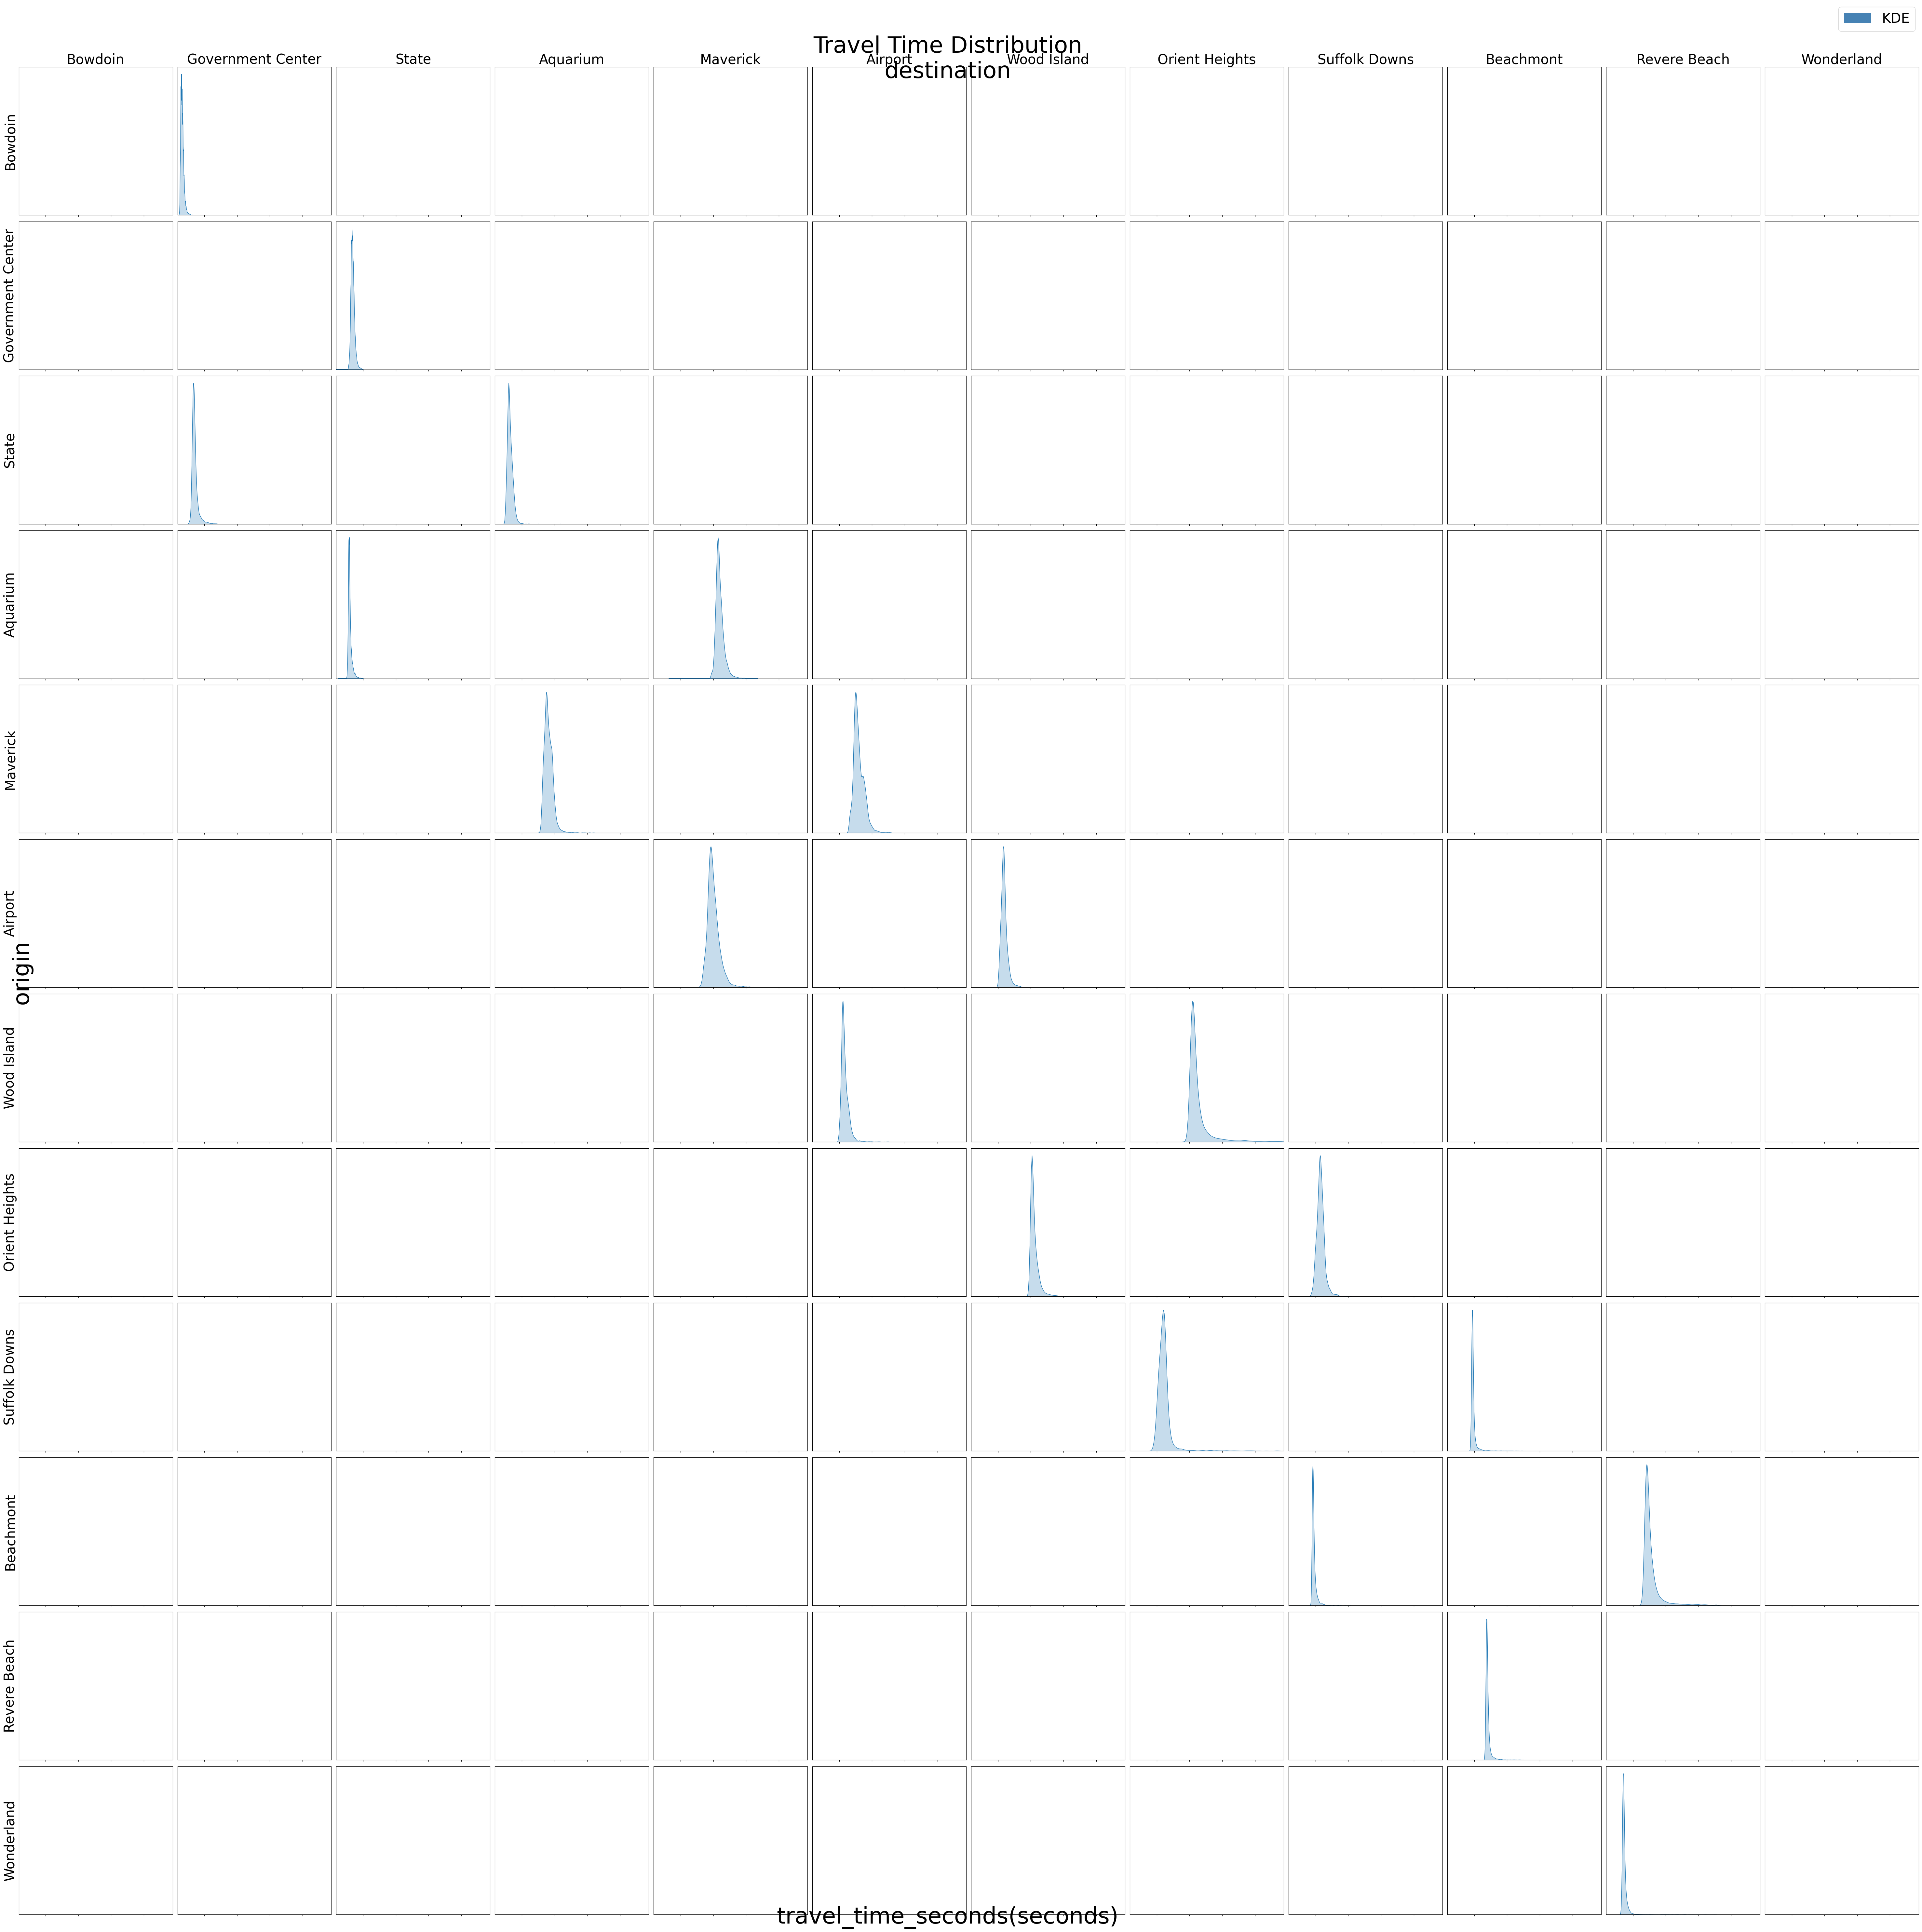

In [133]:
# plot travwl time distribution, between stations
plot_kde(blue, 'travel_time_seconds', blue_stops, 'Travel Time Distribution')

C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local\Temp\ipykernel_20008\1913147849.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=temp, x=feat, fill=True, ax=axes[i, j])
C:\Users\prade\AppData\Local

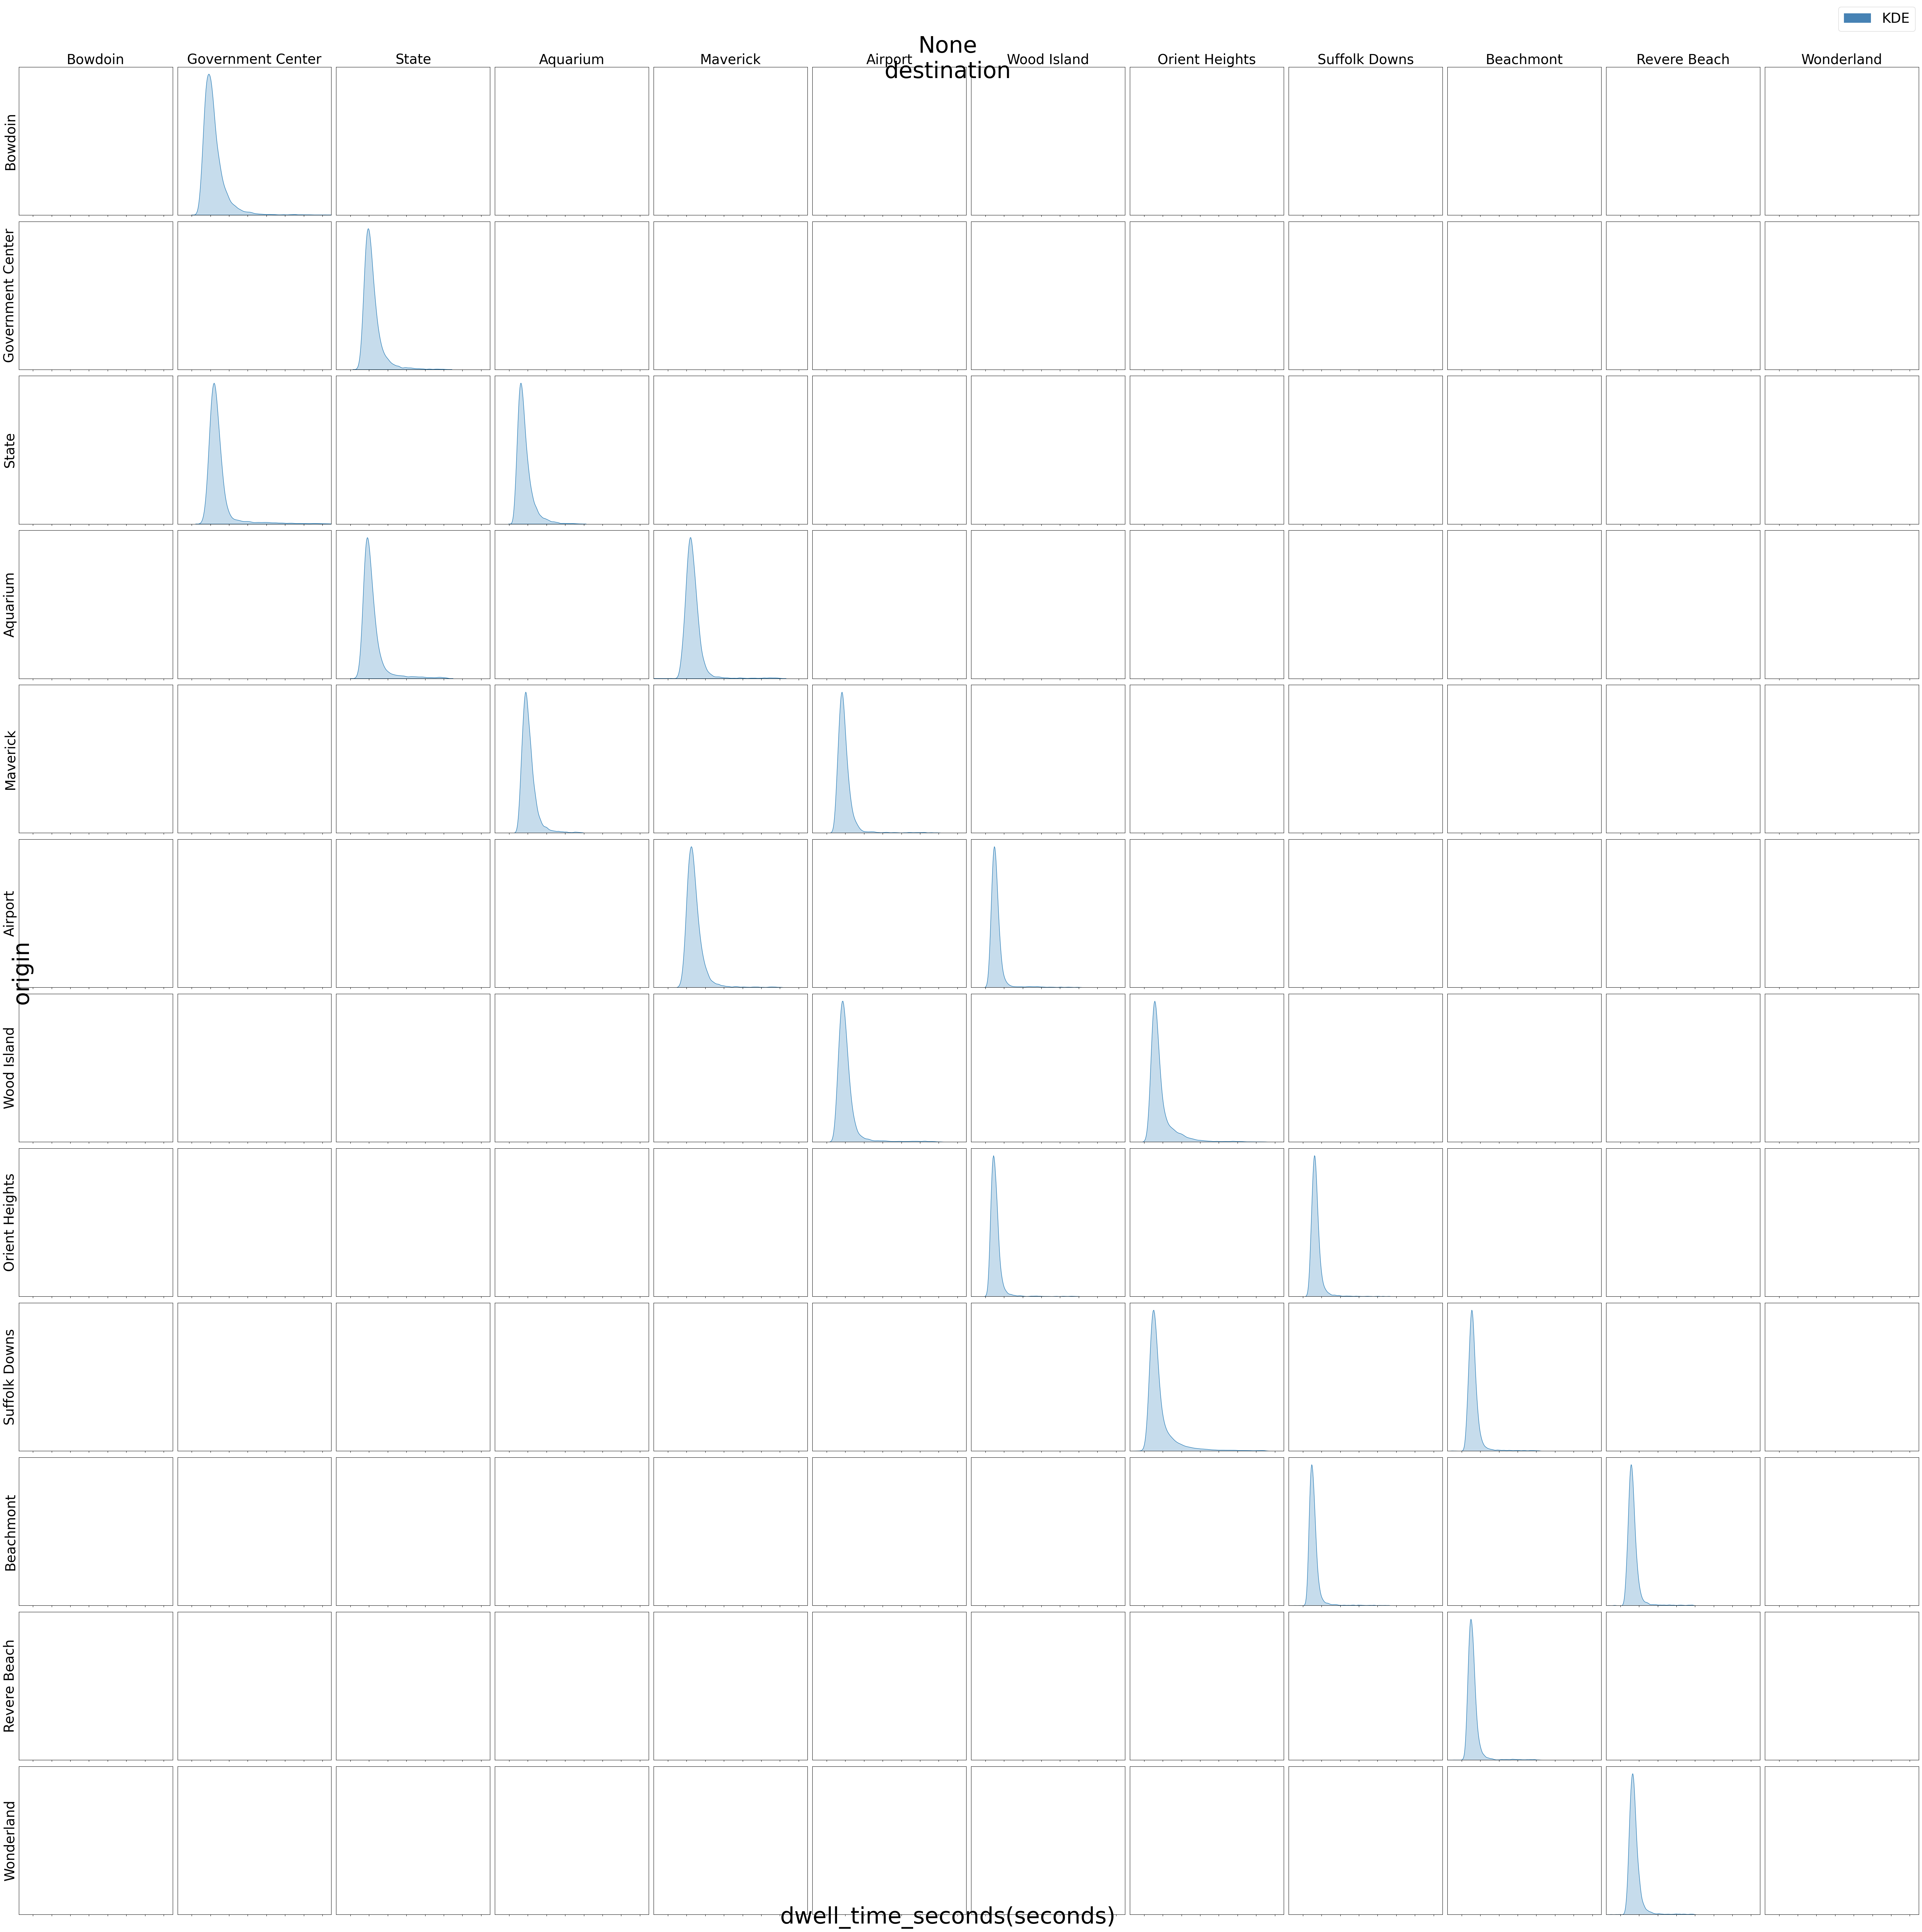

In [134]:
# plot dwell time
plot_kde(blue, 'dwell_time_seconds', blue_stops)

## find best fit distribution

In [135]:
from_station = blue_stops[0]
to_station = blue_stops[1]

temp = blue.loc[(blue['fromstation']==from_station) & (blue['stop_name']==to_station)]

In [136]:
# best fit distribution for travel time
get_aic(blue, 'travel_time_seconds')

weibull_min          76824.40
lognorm              67133.73
gamma                68221.46
expon               106998.34
burr                 61618.20
inverse_gaussian     67311.62
log_logistic         63632.90
dtype: float64


In [137]:
# best fit distribution for dwell time
get_aic(blue, 'dwell_time_seconds')

weibull_min          86135.00
lognorm              77487.85
gamma                79269.84
expon               103522.69
burr                 73374.98
inverse_gaussian     77758.47
log_logistic         74877.17
dtype: float64


In [138]:
# best fit -> burr
distribution = scipy.stats.burr       

## get distribution parameters (sigma, scale)

In [139]:
def get_gamma_params(df, distribution):
    # Output structure: one row per origin-destination pair with fitted params
    ret_df = {
        'from_station':  [],
        'to_station':    [],
        'dwell_params':  [],
        'travel_params': [],
        'direction':     []
    }

    dist = distribution

    # Dynamically extract parameter names from the distribution (e.g. ['a', 'loc', 'scale'])
    key = [s.name for s in dist._shape_info()] + ['loc', 'scale']

    # Iterate over all origin-destination station pairs
    for from_station in df['fromstation'].unique():
        temp = df[df['fromstation']==from_station]
        for to_station in temp['stop_name'].unique():

            # Filter to trips between this specific station pair
            pair = df[(df['stop_name']==to_station) & (df['fromstation']==from_station)]
            dwell_time  = pair['dwell_time_seconds']
            travel_time = pair['travel_time_seconds']

            # Infer direction from mean of direction_id (0=inbound, 1=outbound)
            direction = pair['direction_id'].mean()

            ret_df['from_station'].append(from_station)
            ret_df['to_station'].append(to_station)

            # Fit distribution and store params as a named dict (e.g. {'a': 2.1, 'loc': 0, 'scale': 14.3})
            ret_df['dwell_params'].append(dict(zip(key, dist.fit(dwell_time,  floc=0))))
            ret_df['travel_params'].append(dict(zip(key, dist.fit(travel_time, floc=0))))

            # Convert mean direction to boolean (True=outbound, False=inbound)
            ret_df['direction'].append(bool(direction))

    return pd.DataFrame(ret_df)

In [140]:
# Fit gamma distribution parameters for all origin-destination pairs
params_df = get_gamma_params(blue, distribution)

# Round all parameter values to 2 decimal places for readability and storage efficiency
params_df['dwell_params']  = params_df['dwell_params'].apply(lambda x: {key: round(float(value), 2) for key, value in x.items()})
params_df['travel_params'] = params_df['travel_params'].apply(lambda x: {key: round(float(value), 2) for key, value in x.items()})

In [141]:
params_df

,from_station,to_station,dwell_params,travel_params,direction
0,Orient Heights,Wood Island,"{'c': 9.42, 'd': 3.83, 'loc': 0.0, 'scale': 31...","{'c': 25.69, 'd': 5.75, 'loc': 0.0, 'scale': 9...",False
1,Orient Heights,Suffolk Downs,"{'c': 10.31, 'd': 5.02, 'loc': 0.0, 'scale': 3...","{'c': 16.04, 'd': 1.46, 'loc': 0.0, 'scale': 5...",True
2,Wood Island,Airport,"{'c': 7.22, 'd': 12.6, 'loc': 0.0, 'scale': 32...","{'c': 15.75, 'd': 6.81, 'loc': 0.0, 'scale': 4...",False
3,Wood Island,Orient Heights,"{'c': 5.62, 'd': 773.23, 'loc': 0.0, 'scale': ...","{'c': 14.81, 'd': 22.8, 'loc': 0.0, 'scale': 8...",True
4,Wonderland,Revere Beach,"{'c': 9.92, 'd': 3.68, 'loc': 0.0, 'scale': 36...","{'c': 21.36, 'd': 2690.57, 'loc': 0.0, 'scale'...",False
5,Airport,Maverick,"{'c': 8.2, 'd': 8.81, 'loc': 0.0, 'scale': 42.98}","{'c': 15.46, 'd': 4.01, 'loc': 0.0, 'scale': 8...",False
6,Airport,Wood Island,"{'c': 8.59, 'd': 6.5, 'loc': 0.0, 'scale': 29.58}","{'c': 16.22, 'd': 7.48, 'loc': 0.0, 'scale': 5...",True
7,Revere Beach,Beachmont,"{'c': 9.55, 'd': 3.62, 'loc': 0.0, 'scale': 32...","{'c': 38.28, 'd': 11.29, 'loc': 0.0, 'scale': ...",False
8,Beachmont,Suffolk Downs,"{'c': 10.04, 'd': 5.92, 'loc': 0.0, 'scale': 3...","{'c': 25.08, 'd': 11.22, 'loc': 0.0, 'scale': ...",False
9,Beachmont,Revere Beach,"{'c': 10.1, 'd': 2.99, 'loc': 0.0, 'scale': 35...","{'c': 12.88, 'd': 2357.21, 'loc': 0.0, 'scale'...",True


## complete table; fill in missing edge

In [142]:
'''Terminal layover (4.5 min = 270 s): when a train reaches a terminus (Bowdoin or
Wonderland) it dwells longer than at mid-line stops to allow the crew to walk
to the opposite cab, verify the consist, and wait for the scheduled departure
slot before reversing direction. This minimum recovery time also absorbs minor
schedule deviations before they propagate into the return trip.'''
TARGET_TERMINAL_DWELL = 4.5*60  # seconds

def rescale_burr_to_mean(params: dict, target_mean: float) -> dict:
    """
    Return a copy of params with scale adjusted so the Burr distribution
    hits target_mean, while keeping c, d, and loc unchanged.
    """
    current_mean = scipy.stats.burr.mean(params['c'], params['d'],
                                         loc=params['loc'], scale=params['scale'])
    new_scale = params['scale'] * (target_mean / current_mean)
    return {**params, 'scale': round(float(new_scale), 2)}

'''
Add terminal station segments that are missing from the data:
Bowdoin → Government Center (inbound) and Revere Beach → Wonderland (outbound)
are not observed directly so we mirror their reverse-direction counterparts
i.e. Government Center → Bowdoin params are reused for Bowdoin → Government Center
'''
# Look up the reverse-direction params to use as shape templates
bowdoin_to_govcenter   = params_df[(params_df['from_station']=='Bowdoin')    & (params_df['to_station']=='Government Center')]
wonderland_to_revere   = params_df[(params_df['from_station']=='Wonderland') & (params_df['to_station']=='Revere Beach')]

params_df = pd.concat([params_df,
          pd.DataFrame({
              'from_station': ['Government Center', 'Revere Beach'],
              'to_station':   ['Bowdoin', 'Wonderland'],

            #   Mirror dwell params from the reverse direction but rescale so the
            #   mean equals TARGET_TERMINAL_DWELL - the shape (c, d) is preserved
            #   since terminal layovers follow a similar distribution, just longer
            #   'dwell_params': [
            #       rescale_burr_to_mean(bowdoin_to_govcenter['dwell_params'].iloc[0], TARGET_TERMINAL_DWELL),
            #       rescale_burr_to_mean(wonderland_to_revere['dwell_params'].iloc[0], TARGET_TERMINAL_DWELL),
            #   ],

            'dwell_params': [
                  bowdoin_to_govcenter['dwell_params'].iloc[0],
                  wonderland_to_revere['dwell_params'].iloc[0],
              ],


            #   Travel params are mirrored as-is — the short stub segments
            #   (Gov Center-Bowdoin, Revere Beach↔Wonderland) are assumed
            #   symmetric since no directional data is available in LAMP
              'travel_params': [
                  bowdoin_to_govcenter['travel_params'].iloc[0],
                  wonderland_to_revere['travel_params'].iloc[0],
              ],

              # Bowdoin is inbound terminus (False), Wonderland is outbound terminus (True)
              'direction': [False, True]
          })], ignore_index=True)

In [143]:
params_df

,from_station,to_station,dwell_params,travel_params,direction
0,Orient Heights,Wood Island,"{'c': 9.42, 'd': 3.83, 'loc': 0.0, 'scale': 31...","{'c': 25.69, 'd': 5.75, 'loc': 0.0, 'scale': 9...",False
1,Orient Heights,Suffolk Downs,"{'c': 10.31, 'd': 5.02, 'loc': 0.0, 'scale': 3...","{'c': 16.04, 'd': 1.46, 'loc': 0.0, 'scale': 5...",True
2,Wood Island,Airport,"{'c': 7.22, 'd': 12.6, 'loc': 0.0, 'scale': 32...","{'c': 15.75, 'd': 6.81, 'loc': 0.0, 'scale': 4...",False
3,Wood Island,Orient Heights,"{'c': 5.62, 'd': 773.23, 'loc': 0.0, 'scale': ...","{'c': 14.81, 'd': 22.8, 'loc': 0.0, 'scale': 8...",True
4,Wonderland,Revere Beach,"{'c': 9.92, 'd': 3.68, 'loc': 0.0, 'scale': 36...","{'c': 21.36, 'd': 2690.57, 'loc': 0.0, 'scale'...",False
5,Airport,Maverick,"{'c': 8.2, 'd': 8.81, 'loc': 0.0, 'scale': 42.98}","{'c': 15.46, 'd': 4.01, 'loc': 0.0, 'scale': 8...",False
6,Airport,Wood Island,"{'c': 8.59, 'd': 6.5, 'loc': 0.0, 'scale': 29.58}","{'c': 16.22, 'd': 7.48, 'loc': 0.0, 'scale': 5...",True
7,Revere Beach,Beachmont,"{'c': 9.55, 'd': 3.62, 'loc': 0.0, 'scale': 32...","{'c': 38.28, 'd': 11.29, 'loc': 0.0, 'scale': ...",False
8,Beachmont,Suffolk Downs,"{'c': 10.04, 'd': 5.92, 'loc': 0.0, 'scale': 3...","{'c': 25.08, 'd': 11.22, 'loc': 0.0, 'scale': ...",False
9,Beachmont,Revere Beach,"{'c': 10.1, 'd': 2.99, 'loc': 0.0, 'scale': 35...","{'c': 12.88, 'd': 2357.21, 'loc': 0.0, 'scale'...",True


## compare distribution from empirical distribution

In [144]:
def compare_kde(df1, feat1, df2, feat2, ind_col, distribution, title=None):
    l = len(ind_col)

    # Create l x l grid — one cell per (from station, to station) pair
    fig, axes = plt.subplots(l, l, figsize=(5*l, 5*l))

    # Shared axis labels and title for the full grid
    fig.supxlabel(f'{feat1}(seconds)', fontsize=50)
    fig.supylabel('origin\n', fontsize=50)
    fig.suptitle(f'{title}\n\ndestination\n', fontsize=50)

    # x axis limit
    x_max, x_min = df1[feat1].max(), df1[feat1].min()

    for i in range(l):
        for j in range(l):
            ax = axes[i, j]
            
            # Plot KDE of observed data for this station pair
            temp_obs = df1.loc[
                (df1['fromstation'] == ind_col[i]) & 
                (df1['stop_name']   == ind_col[j])
            ]
            if temp_obs[feat1].nunique() > 1:
                sns.kdeplot(data=temp_obs, x=feat1, fill=True, ax=ax, warn_singular=False, color='tab:blue')

            # Overlay KDE of synthetic samples drawn from the fitted distribution
            temp_fit = df2.loc[
                (df2['from_station'] == ind_col[i]) & 
                (df2['to_station']   == ind_col[j])
            ]
            if not temp_fit.empty:
                params = temp_fit[feat2].iloc[0]
                # Sample from fitted distribution using stored params and plot
                if isinstance(params, dict):
                    data = distribution(**params).rvs(size=4000)
                    if data.std() > 0:
                        sns.kdeplot(data=data, fill=True, ax=ax, warn_singular=False, color='tab:orange')

            # Clear individual subplot axis labels (handled by supxlabel/supylabel)
            ax.set_xlabel('')
            ax.set_ylabel('')

            # Label left column with origin station name
            if j == 0:
                ax.set_ylabel(ind_col[i], fontsize=30)

            # Label top row with destination station name
            if i == 0:
                ax.set_title(ind_col[j], fontsize=30)

            # Remove tick labels and ticks for cleaner grid appearance
            ax.tick_params(labelbottom=False, labelleft=False)
            ax.set_xticks([])
            ax.set_yticks([])

    palette = sns.color_palette()
    sns_blue   = palette[0]  # default seaborn blue   → observed KDE
    sns_orange = palette[1]  # default seaborn orange → fitted Burr

    legend_elements = [
        Patch(facecolor=sns_blue,   label='KDE'),
        Patch(facecolor=sns_orange, label='Burr Fit')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=30)
    plt.tight_layout()
    fig.savefig(f'{title}.svg', bbox_inches='tight', format='svg')
    plt.show()

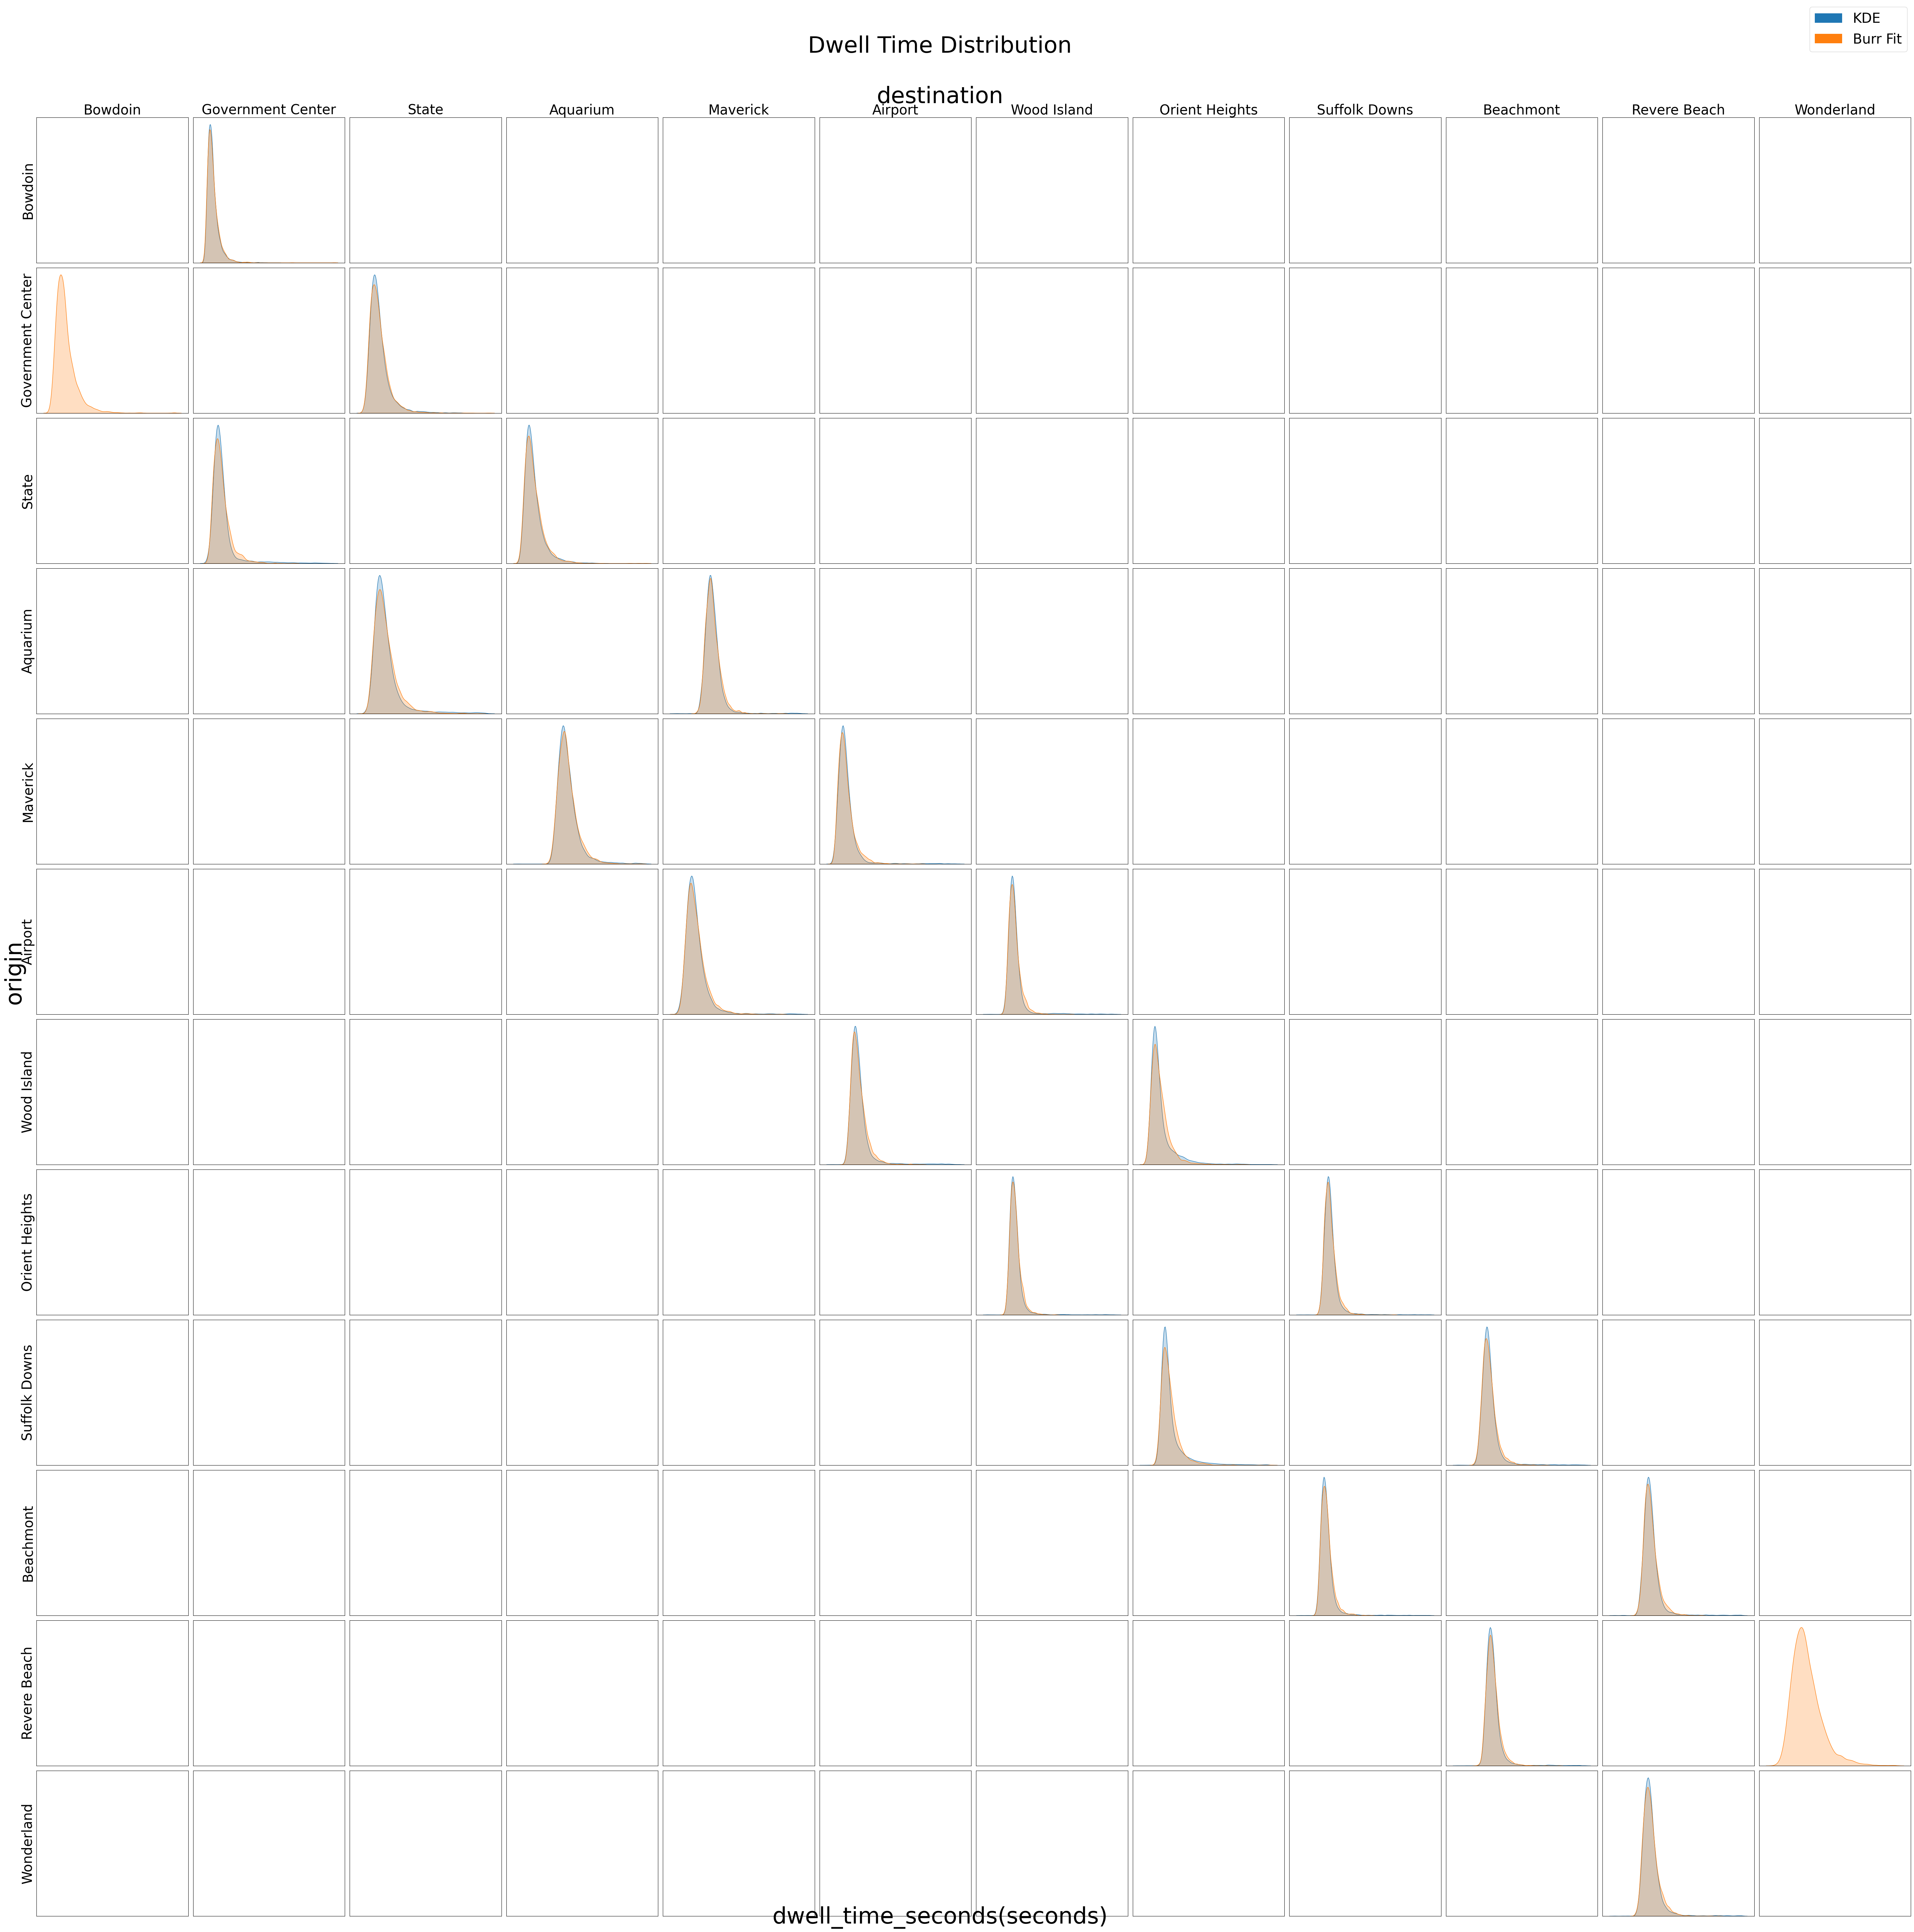

In [145]:
# compare dwell time
compare_kde(blue, 'dwell_time_seconds', params_df, 'dwell_params', blue_stops, distribution, 'Dwell Time Distribution')

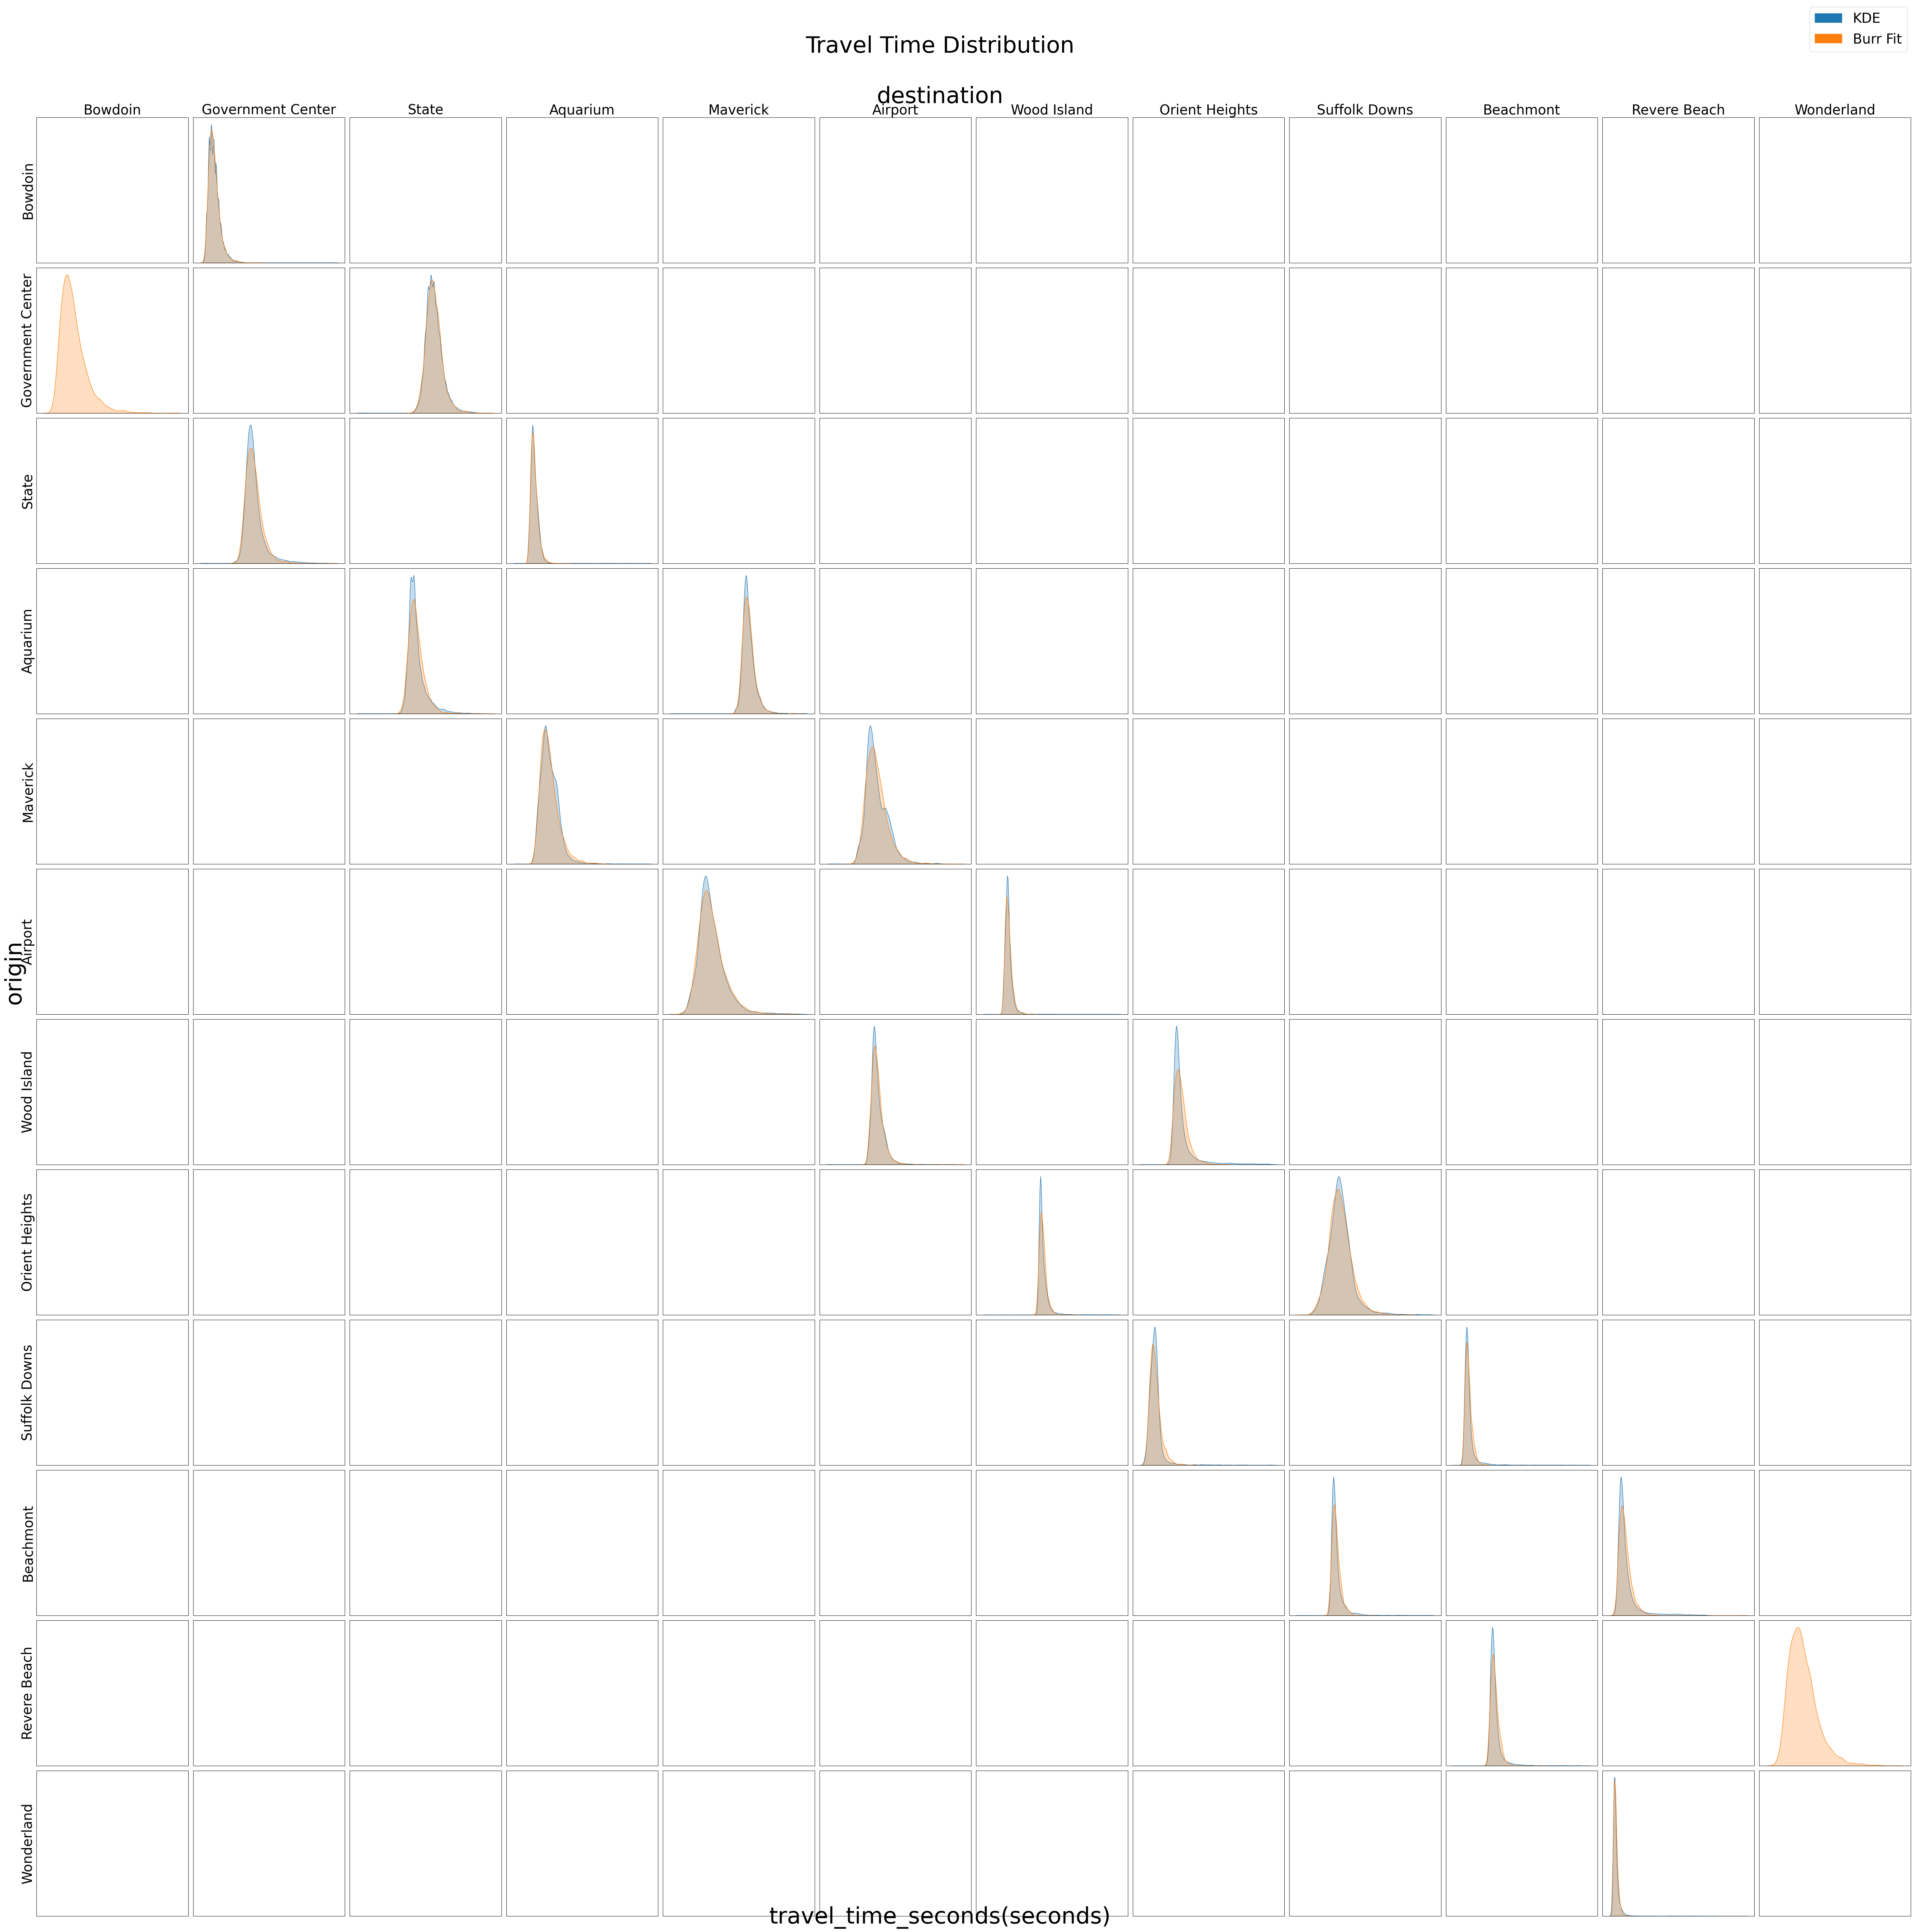

In [146]:
# compare travel time
compare_kde(blue, 'travel_time_seconds', params_df, 'travel_params', blue_stops, distribution, 'Travel Time Distribution')

In [147]:
blue_stops = ['Bowdoin' ,'Government Center', 'State', 'Aquarium',
                'Maverick', 'Airport', 'Wood Island',
                'Orient Heights', 'Suffolk Downs', 
                'Beachmont', 'Revere Beach', 'Wonderland']


In [148]:
def generate_stations(stops, df):
    # Initialise network dict: each station has params for both directions (True=outbound, False=inbound)
    station_network = {
        station: {True: {}, False: {}}
        for station in stops
    }

    for station in stops:
        for b in [True, False]:
            # Look up outgoing trip from this station in direction b
            # to get the next station and travel time distribution params
            temp = df[(df['from_station']==station) & (df['direction']==b)]
            if not(temp.empty):
                name = temp['to_station'].iloc[0]
                travel_params = temp['travel_params'].iloc[0]

                # Store next station name and travel params for this direction
                station_network[station][b]['next_station'] = {
                    'name':          name,
                    'travel_params': travel_params
                }

            # Look up incoming trip to this station in direction b
            # to get the dwell time distribution params on arrival
            temp = df[(df['to_station']==station) & (df['direction']==b)]
            if not(temp.empty):
                dwell_params = temp['dwell_params'].iloc[0]

                # Store dwell params for trains arriving at this station
                station_network[station][b]['dwell_params'] = dwell_params

    return station_network

In [149]:
blue_network = generate_stations(blue_stops, params_df)

In [150]:
pprint(blue_network)

{'Airport': {False: {'dwell_params': {'c': 7.22,
                                      'd': 12.6,
                                      'loc': 0.0,
                                      'scale': 32.45},
                     'next_station': {'name': 'Maverick',
                                      'travel_params': {'c': 15.46,
                                                        'd': 4.01,
                                                        'loc': 0.0,
                                                        'scale': 88.74}}},
             True: {'dwell_params': {'c': 7.75,
                                     'd': 509.18,
                                     'loc': 0.0,
                                     'scale': 20.01},
                    'next_station': {'name': 'Wood Island',
                                     'travel_params': {'c': 16.22,
                                                       'd': 7.48,
                                                       'loc': 0.0,


## export data

In [151]:
# save as pickle
with open(r'.\data\blue_network.pkl', 'wb') as f:
    pickle.dump(blue_network, f)